In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=150, noise=0.25, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (105, 2) | Test : (45, 2)


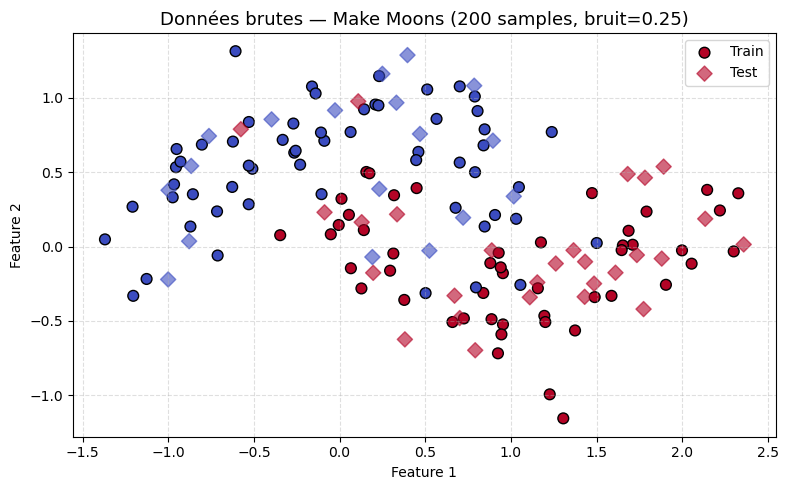

In [ ]:
# Visualisation des données brutes 
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm',
            edgecolors='k', s=60, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm',
            marker='D', alpha=0.6, s=60, label='Test')
plt.title("Données brutes — Make Moons (200 samples, bruit=0.25)", fontsize=13)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [3]:

poly = PolynomialFeatures(degree=8, include_bias=False)
scaler = StandardScaler()

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t  = scaler.transform(poly.transform(X_test))

print(f"Nombre de features après transformation polynomiale degré 8 : {X_train_t.shape[1]}")

Nombre de features après transformation polynomiale degré 8 : 44


## Sans Régularisation
Le modèle est libre de prendre n'importe quels coefficients → risque fort d'**overfitting**.

In [4]:
clf_no_reg = LogisticRegression(penalty=None, max_iter=2000, random_state=0)
clf_no_reg.fit(X_train_t, y_train)

print("=== Sans Régularisation ===")
print(f"  Train accuracy : {clf_no_reg.score(X_train_t, y_train):.4f}")
print(f"  Test  accuracy : {clf_no_reg.score(X_test_t,  y_test):.4f}")
print(f"  Gap            : {clf_no_reg.score(X_train_t, y_train) - clf_no_reg.score(X_test_t, y_test):.4f}")

=== Sans Régularisation ===
  Train accuracy : 1.0000
  Test  accuracy : 0.7556
  Gap            : 0.2444


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


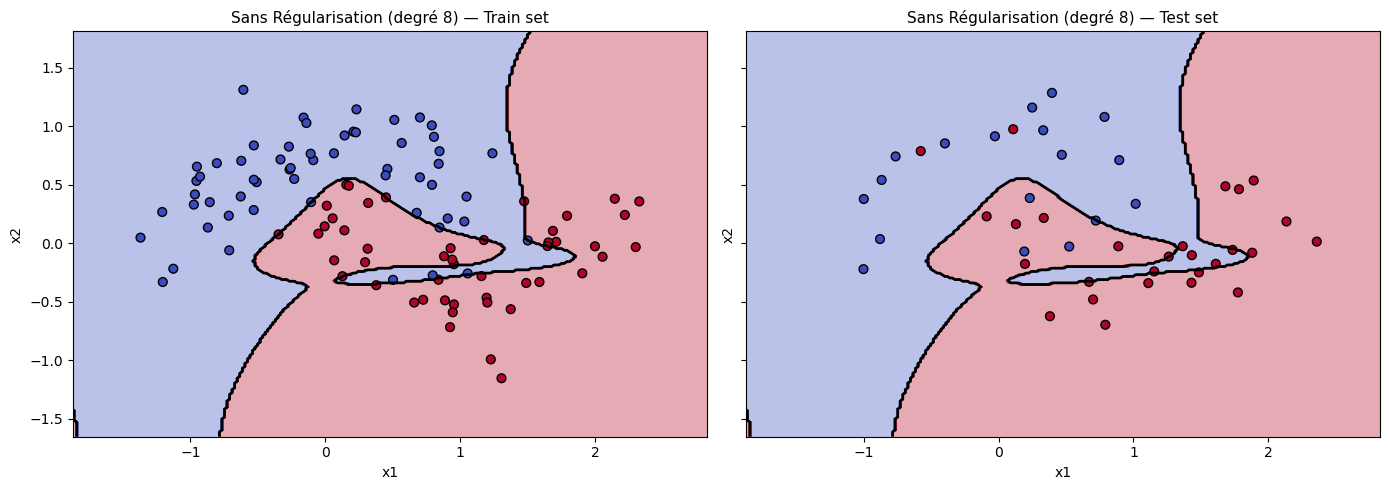

In [ ]:
# Fonction utilitaire pour tracer la frontière de décision 
def plot_boundary(model, poly, scaler, X_train, y_train, X_test, y_test, title):
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                         np.linspace(y_min, y_max, 250))
    grid   = np.c_[xx.ravel(), yy.ravel()]
    grid_t = scaler.transform(poly.transform(grid))
    Z = model.predict_proba(grid_t)[:, 1].reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    for ax, X_p, y_p, subtitle in [
        (axes[0], X_train, y_train, "Train set"),
        (axes[1], X_test,  y_test,  "Test set"),
    ]:
        ax.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.35)
        ax.contour(xx,  yy, Z, levels=[0.5], colors='k', linewidths=2)
        ax.scatter(X_p[:, 0], X_p[:, 1], c=y_p, cmap='coolwarm',
                   edgecolors='k', s=40)
        ax.set_title(f"{title} — {subtitle}", fontsize=11)
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
    plt.tight_layout()
    plt.show()

plot_boundary(clf_no_reg, poly, scaler, X_train, y_train, X_test, y_test,
              "Sans Régularisation (degré 8)")

## Régularisation L1 (Lasso)
L1 pousse certains coefficients exactement à **zéro** → sélection automatique de features.

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== Avec Régularisation L1 (C=0.8) ===
  Train accuracy    : 0.8762
  Test  accuracy    : 0.8667
  Coefficients nuls : 37 / 44


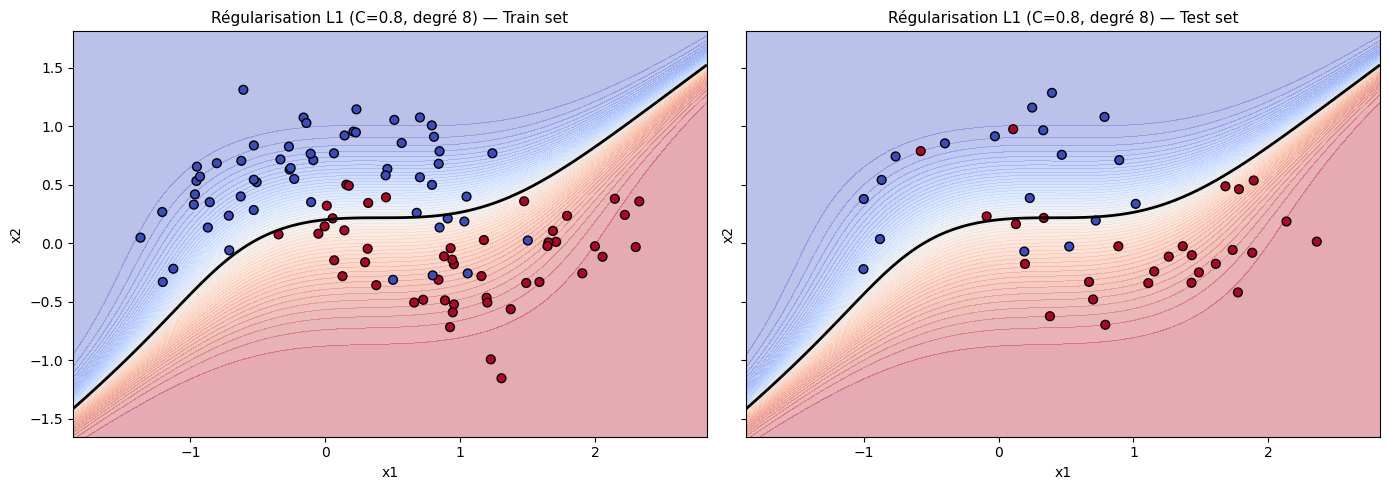

In [6]:
clf_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.8,
                             max_iter=2000, random_state=0)
clf_l1.fit(X_train_t, y_train)

n_zeros = (clf_l1.coef_ == 0).sum()
total   = clf_l1.coef_.size

print("=== Avec Régularisation L1 (C=0.8) ===")
print(f"  Train accuracy    : {clf_l1.score(X_train_t, y_train):.4f}")
print(f"  Test  accuracy    : {clf_l1.score(X_test_t,  y_test):.4f}")
print(f"  Coefficients nuls : {n_zeros} / {total}")

plot_boundary(clf_l1, poly, scaler, X_train, y_train, X_test, y_test,
              "Régularisation L1 (C=0.8, degré 8)")

## Régularisation L2 (Ridge)
L2 réduit l'amplitude de **tous** les coefficients mais ne les annule pas totalement.

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== Avec Régularisation L2 (C=0.8) ===
  Train accuracy : 0.8762
  Test  accuracy : 0.8889


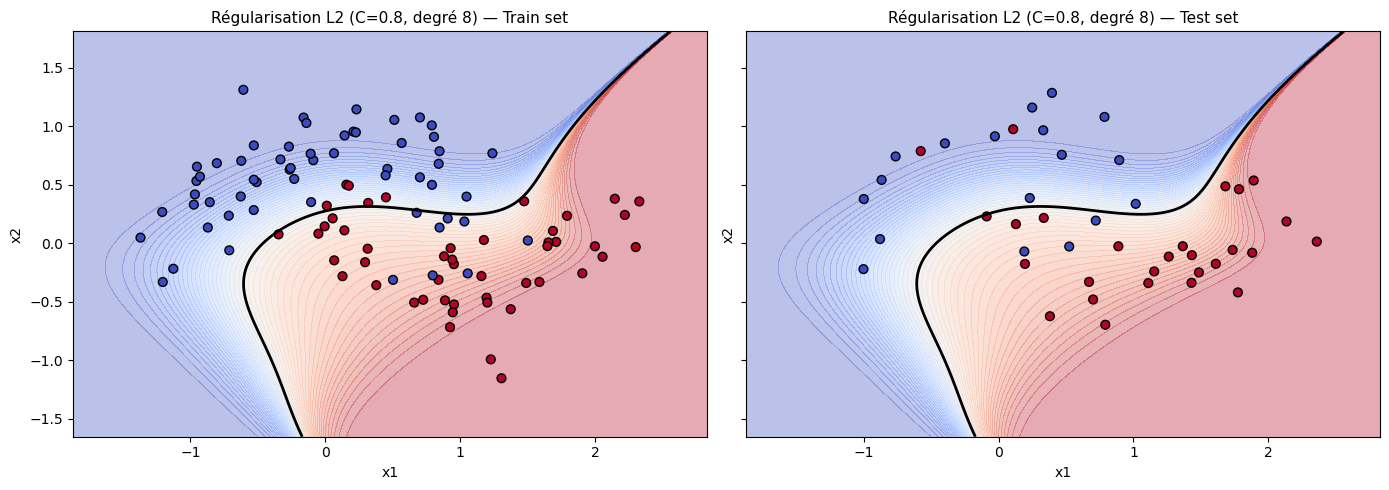

In [7]:
clf_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=0.8,
                             max_iter=2000, random_state=0)
clf_l2.fit(X_train_t, y_train)

print("=== Avec Régularisation L2 (C=0.8) ===")
print(f"  Train accuracy : {clf_l2.score(X_train_t, y_train):.4f}")
print(f"  Test  accuracy : {clf_l2.score(X_test_t,  y_test):.4f}")

plot_boundary(clf_l2, poly, scaler, X_train, y_train, X_test, y_test,
              "Régularisation L2 (C=0.8, degré 8)")

## Comparaison visuelle 

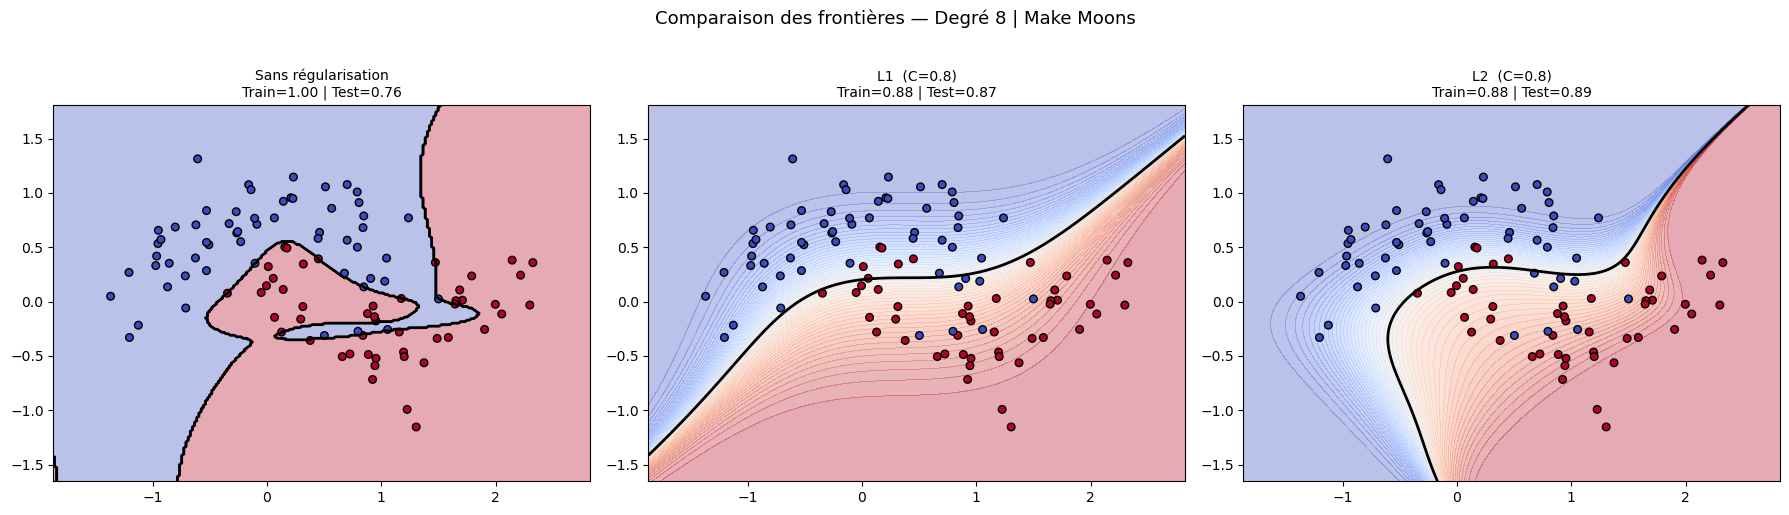

In [8]:
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                     np.linspace(y_min, y_max, 250))
grid   = np.c_[xx.ravel(), yy.ravel()]
grid_t = scaler.transform(poly.transform(grid))

modeles = [
    ("Sans régularisation", clf_no_reg),
    ("L1  (C=0.8)",         clf_l1),
    ("L2  (C=0.8)",         clf_l2),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (titre, model) in zip(axes, modeles):
    Z = model.predict_proba(grid_t)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.35)
    ax.contour(xx,  yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap='coolwarm', edgecolors='k', s=30)
    tr = model.score(X_train_t, y_train)
    te = model.score(X_test_t,  y_test)
    ax.set_title(f"{titre}\nTrain={tr:.2f} | Test={te:.2f}", fontsize=10)

plt.suptitle("Comparaison des frontières — Degré 8 | Make Moons",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Ici les données ont **50 features** → on ne peut pas les visualiser directement.  
On utilise **PCA (2 composantes)** pour projeter en 2D et visualiser la frontière.

In [9]:
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# Paramètres modifiés : n_samples=2000 (au lieu de 3000), random_state=7
X, y = make_classification(n_samples=2000, n_features=50, n_classes=2,
                            n_informative=15, random_state=7)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

print(f"Dataset shape : {X.shape}")
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Dataset shape : (2000, 50)
Train : (1400, 50) | Test : (600, 50)


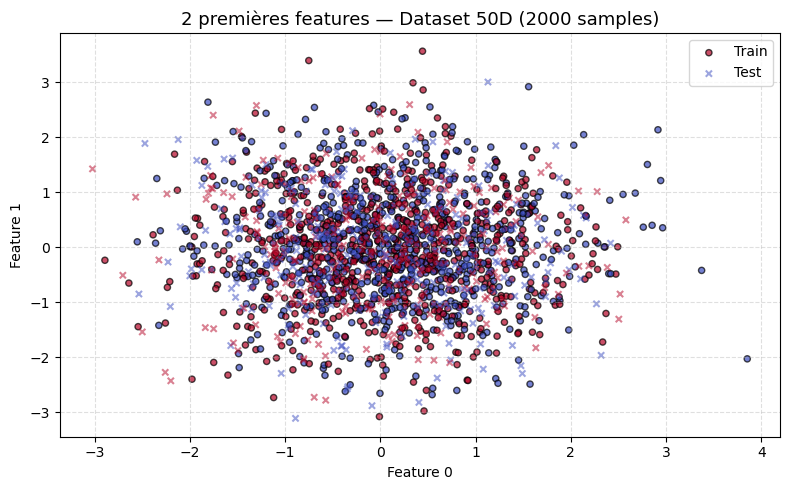

In [10]:
# ── Visualisation des 2 premières features brutes ──
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm',
            edgecolors='k', s=20, alpha=0.7, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm',
            marker='x', alpha=0.5, s=20, label='Test')
plt.title("2 premières features — Dataset 50D (2000 samples)", fontsize=13)
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## Fonction de visualisation PCA 2D
Comme les données sont en 50D, on entraîne le modèle en 50D, puis on projette
uniquement la **grille de visualisation** via PCA → espace 2D.

In [11]:
def train_and_visualize_pca(degree, penalty, solver, C=1.0, title=""):
    """Entraîne un modèle en espace complet et visualise via PCA 2D."""
    # Transformation dans l'espace complet
    poly_   = PolynomialFeatures(degree=degree, include_bias=False)
    scaler_ = StandardScaler()
    Xtr_t = scaler_.fit_transform(poly_.fit_transform(X_train))
    Xte_t = scaler_.transform(poly_.transform(X_test))

    # Entraînement
    kwargs = dict(max_iter=1000, random_state=7)
    if penalty is None:
        clf_ = LogisticRegression(penalty=None, solver='lbfgs', **kwargs)
    elif penalty == 'l1':
        clf_ = LogisticRegression(penalty='l1', solver='liblinear', C=C, **kwargs)
    else:
        clf_ = LogisticRegression(penalty='l2', solver='lbfgs', C=C, **kwargs)

    clf_.fit(Xtr_t, y_train)
    acc_tr = clf_.score(Xtr_t, y_train)
    acc_te = clf_.score(Xte_t, y_test)
    print(f"{title:40s} | Train: {acc_tr:.4f} | Test: {acc_te:.4f} | Gap: {acc_tr-acc_te:.4f}")

    # PCA 2D pour visualisation
    pca_ = PCA(n_components=2)
    Xtr_2d = pca_.fit_transform(X_train)
    Xte_2d = pca_.transform(X_test)

    poly_2d   = PolynomialFeatures(degree=degree, include_bias=False)
    scaler_2d = StandardScaler()
    Xtr_2d_t = scaler_2d.fit_transform(poly_2d.fit_transform(Xtr_2d))

    clf_viz = LogisticRegression(**({'penalty': None, 'solver': 'lbfgs'} if penalty is None
                                    else {'penalty': penalty, 'solver': solver, 'C': C}),
                                 max_iter=1000, random_state=7)
    clf_viz.fit(Xtr_2d_t, y_train)

    xmn, xmx = Xtr_2d[:, 0].min()-0.5, Xtr_2d[:, 0].max()+0.5
    ymn, ymx = Xtr_2d[:, 1].min()-0.5, Xtr_2d[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(xmn, xmx, 250),
                         np.linspace(ymn, ymx, 250))
    grid_t2 = scaler_2d.transform(poly_2d.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = clf_viz.predict_proba(grid_t2)[:, 1].reshape(xx.shape)

    plt.figure(figsize=(9, 5))
    plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.35)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1], c=y_train, cmap='coolwarm',
                edgecolors='k', s=20, label='Train')
    plt.scatter(Xte_2d[:, 0], Xte_2d[:, 1], c=y_test, cmap='coolwarm',
                marker='x', alpha=0.7, s=20, label='Test')
    plt.title(f"{title}\nTrain={acc_tr:.3f} | Test={acc_te:.3f}", fontsize=11)
    plt.xlabel("PCA Composante 1"); plt.ylabel("PCA Composante 2")
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout(); plt.show()

## Degré 2 : Sans / L1 / L2

DEGRÉ 2


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Degré 2 — Sans régularisation            | Train: 1.0000 | Test: 0.8900 | Gap: 0.1100


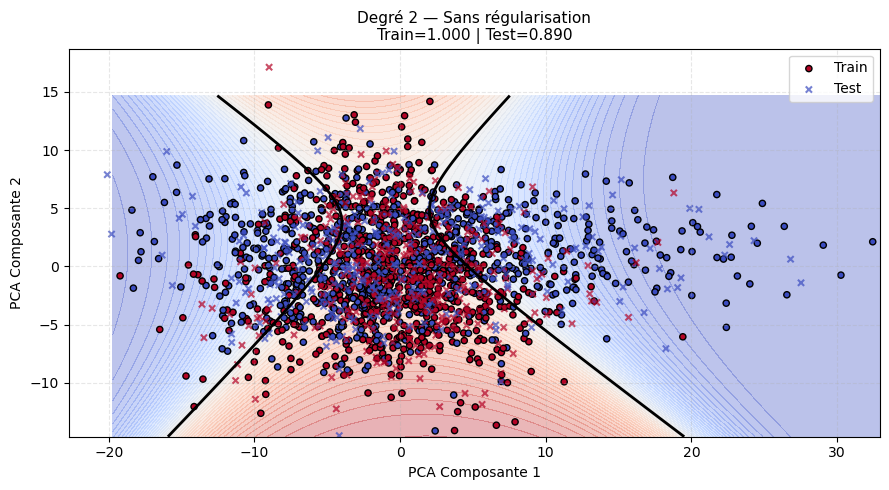

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Degré 2 — L1 (C=1.0)                     | Train: 1.0000 | Test: 0.9317 | Gap: 0.0683


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


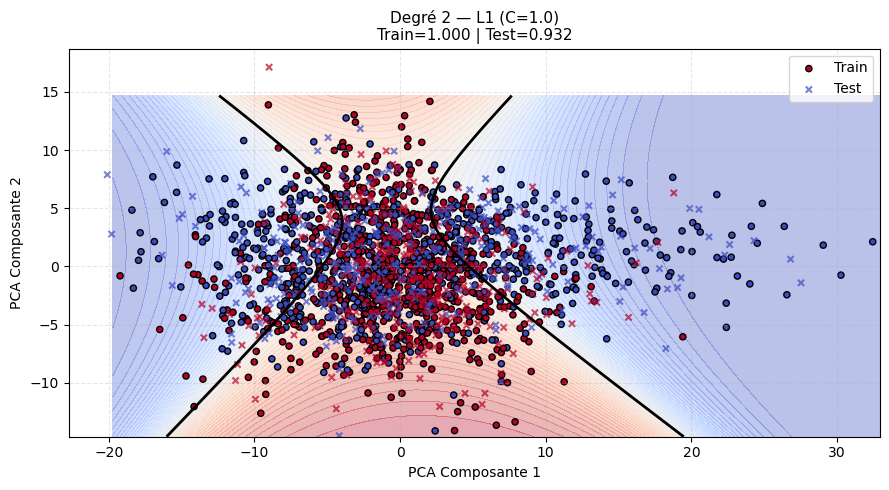

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Degré 2 — L2 (C=1.0)                     | Train: 1.0000 | Test: 0.8983 | Gap: 0.1017


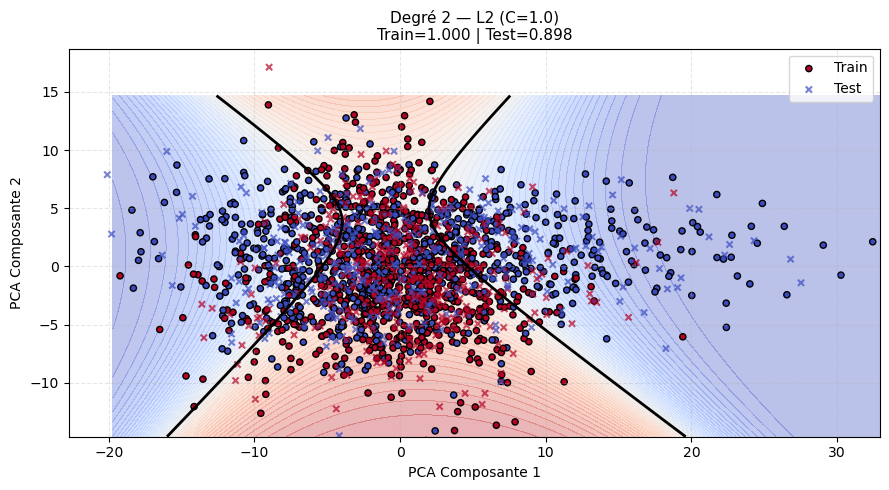

In [12]:
print("=" * 70)
print("DEGRÉ 2")
print("=" * 70)
train_and_visualize_pca(2, None,  'lbfgs',     title="Degré 2 — Sans régularisation")
train_and_visualize_pca(2, 'l1', 'liblinear', C=1.0, title="Degré 2 — L1 (C=1.0)")
train_and_visualize_pca(2, 'l2', 'lbfgs',     C=1.0, title="Degré 2 — L2 (C=1.0)")

## Degré 3 : Sans / L1 / L2

DEGRÉ 3


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Degré 3 — Sans régularisation            | Train: 1.0000 | Test: 0.8900 | Gap: 0.1100


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


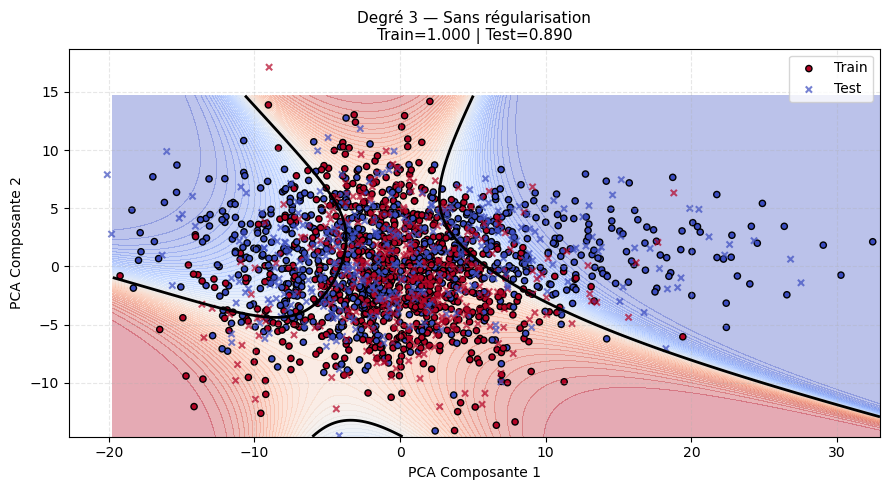

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Degré 3 — L1 (C=1.0)                     | Train: 1.0000 | Test: 0.9267 | Gap: 0.0733


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


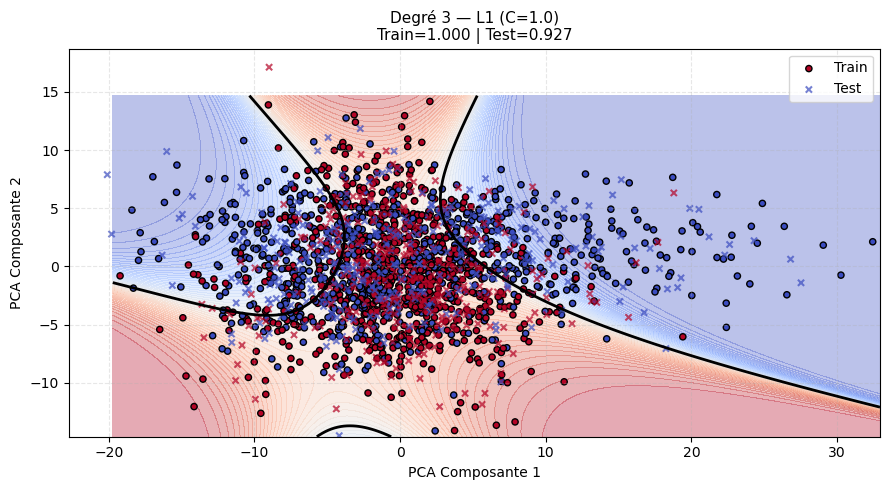

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Degré 3 — L2 (C=1.0)                     | Train: 1.0000 | Test: 0.9067 | Gap: 0.0933


/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


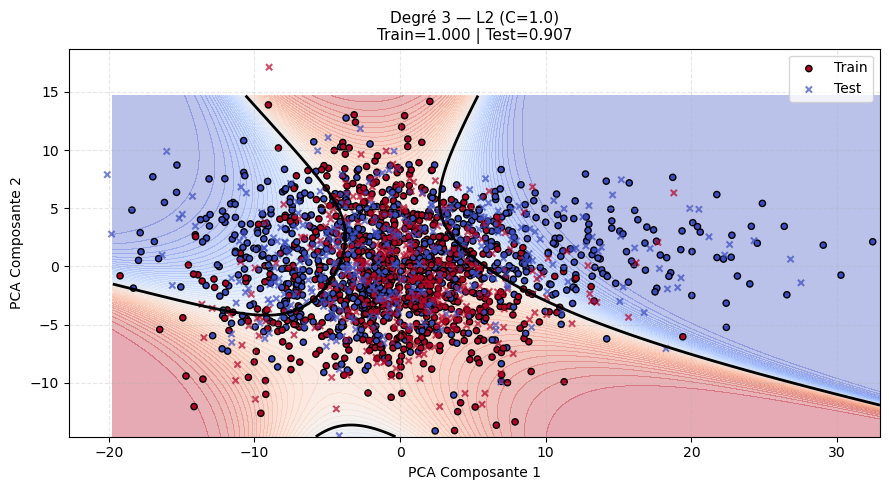

In [13]:
print("=" * 70)
print("DEGRÉ 3")
print("=" * 70)
train_and_visualize_pca(3, None,  'lbfgs',     title="Degré 3 — Sans régularisation")
train_and_visualize_pca(3, 'l1', 'liblinear', C=1.0, title="Degré 3 — L1 (C=1.0)")
train_and_visualize_pca(3, 'l2', 'lbfgs',     C=1.0, title="Degré 3 — L2 (C=1.0)")

## Tableau récapitulatif : Comparaison de tous les modèles

In [15]:
import pandas as pd

resultats = []
configs = [
    (2, None,  'lbfgs',     1.0, "D2 — Aucune"),
    (2, 'l1', 'liblinear', 1.0, "D2 — L1"),
    (2, 'l2', 'lbfgs',     1.0, "D2 — L2"),
    (3, None,  'lbfgs',     1.0, "D3 — Aucune"),
    (3, 'l1', 'liblinear', 1.0, "D3 — L1"),
    (3, 'l2', 'lbfgs',     1.0, "D3 — L2"),
]

for deg, pen, solv, c, nom in configs:
    poly_   = PolynomialFeatures(degree=deg, include_bias=False)
    scaler_ = StandardScaler()
    Xtr_t = scaler_.fit_transform(poly_.fit_transform(X_train))
    Xte_t = scaler_.transform(poly_.transform(X_test))
    kwargs = dict(max_iter=1000, random_state=7)
    if pen is None:
        clf_ = LogisticRegression(penalty=None, solver='lbfgs', **kwargs)
    elif pen == 'l1':
        clf_ = LogisticRegression(penalty='l1', solver='liblinear', C=c, **kwargs)
    else:
        clf_ = LogisticRegression(penalty='l2', solver='lbfgs', C=c, **kwargs)
    clf_.fit(Xtr_t, y_train)
    tr = clf_.score(Xtr_t, y_train)
    te = clf_.score(Xte_t, y_test)
    resultats.append({"Modèle": nom, "Train": round(tr, 4),
                      "Test": round(te, 4), "Gap": round(tr-te, 4),
                      "Overfitting": " Oui" if tr-te > 0.03 else "Non"})

df_res = pd.DataFrame(resultats)
print(df_res.to_string(index=False))

/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hajar/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio o

     Modèle  Train   Test    Gap Overfitting
D2 — Aucune    1.0 0.8900 0.1100         Oui
    D2 — L1    1.0 0.9317 0.0683         Oui
    D2 — L2    1.0 0.8983 0.1017         Oui
D3 — Aucune    1.0 0.8900 0.1100         Oui
    D3 — L1    1.0 0.9267 0.0733         Oui
    D3 — L2    1.0 0.9067 0.0933         Oui


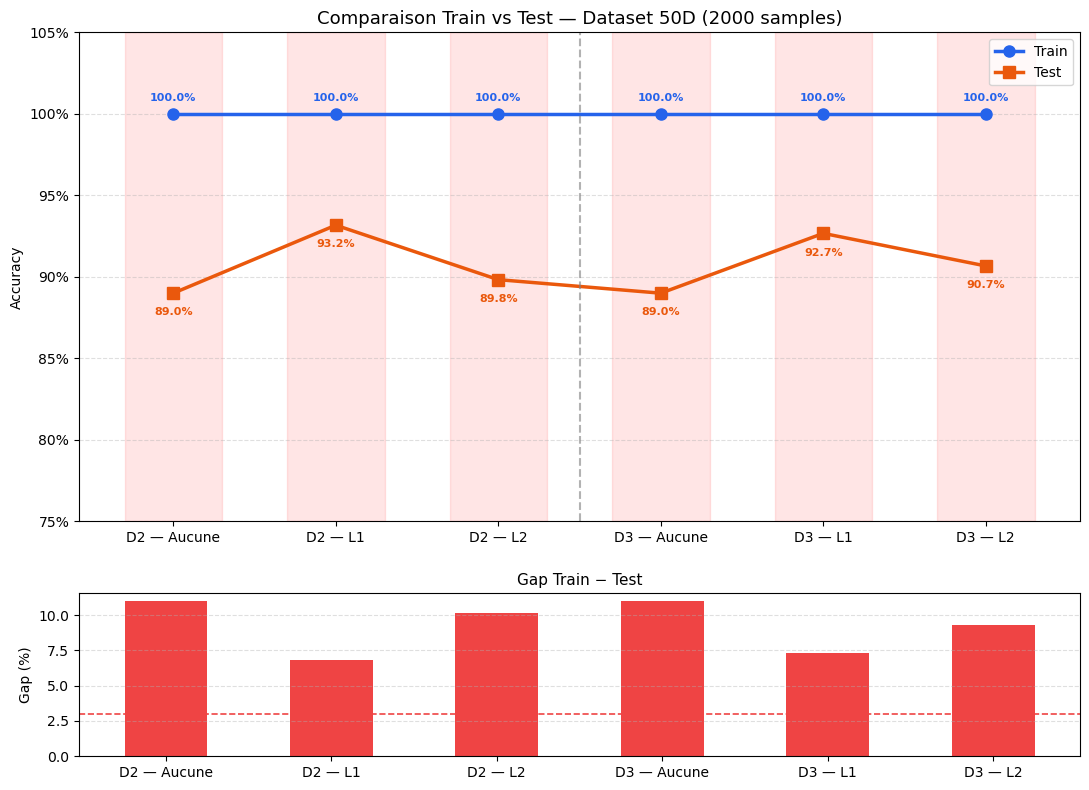

In [16]:
noms = df_res["Modèle"].tolist()
s_tr = df_res["Train"].tolist()
s_te = df_res["Test"].tolist()
gaps = df_res["Gap"].tolist()
x    = np.arange(len(noms))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8),
                                gridspec_kw={'height_ratios': [3, 1]})

# Zones d'overfitting
for i, g in enumerate(gaps):
    if g > 0.03:
        ax1.axvspan(i-0.3, i+0.3, color='red', alpha=0.1)

ax1.plot(x, s_tr, 'o-', color='#2563eb', linewidth=2.5, markersize=8, label='Train')
ax1.plot(x, s_te, 's-', color='#ea580c', linewidth=2.5, markersize=8, label='Test')
for i in range(len(noms)):
    ax1.annotate(f"{s_tr[i]*100:.1f}%", (x[i], s_tr[i]),
                 xytext=(0, 9), textcoords='offset points',
                 ha='center', fontsize=8, color='#2563eb', fontweight='bold')
    ax1.annotate(f"{s_te[i]*100:.1f}%", (x[i], s_te[i]),
                 xytext=(0, -16), textcoords='offset points',
                 ha='center', fontsize=8, color='#ea580c', fontweight='bold')

ax1.axvline(2.5, color='gray', linestyle='--', alpha=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(noms, fontsize=10)
ax1.set_ylim(0.75, 1.05); ax1.set_ylabel("Accuracy")
ax1.set_title("Comparaison Train vs Test — Dataset 50D (2000 samples)", fontsize=13)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.4)

colors = ['#ef4444' if g > 0.03 else '#94a3b8' for g in gaps]
ax2.bar(x, [g*100 for g in gaps], color=colors, width=0.5)
ax2.axhline(3, color='#ef4444', linestyle='--', linewidth=1.2)
ax2.set_xticks(x); ax2.set_xticklabels(noms, fontsize=10)
ax2.set_ylabel("Gap (%)"); ax2.set_title("Gap Train − Test", fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(h_pad=2)
plt.show()